In [91]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")

# Aperçu
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           100000 non-null  str    
 1   AGE_CLI      99524 non-null   float64
 2   B_MAT        98620 non-null   float64
 3   B_RESMAT     98620 non-null   float64
 4   CLASSACT     100000 non-null  int64  
 5   CSP          97522 non-null   float64
 6   DARRET       100000 non-null  int64  
 7   E_EAD        98620 non-null   float64
 8   E_OFF        98620 non-null   float64
 9   E_ONB        98620 non-null   float64
 10  MREVAU       99954 non-null   float64
 11  MREVNU       99954 non-null   float64
 12  MREVTOT      99954 non-null   float64
 13  MTECH        100000 non-null  float64
 14  NBIMP        100000 non-null  int64  
 15  NB_ECH       100000 non-null  int64  
 16  produit      100000 non-null  str    
 17  RA           100000 non-null  float64
 18  Tx           95114 non-null   float6

In [92]:
cols_to_drop = [
    "Unnamed: 19",
    "MREVAU",
    "MREVNU"
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


In [93]:
# DARRET au format YYYYMM → datetime
df["DARRET"] = pd.to_datetime(
    df["DARRET"].astype(str) + "01",
    format="%Y%m%d",
    errors="coerce"
)

df["DARRET"].isna().mean()


np.float64(0.0)

In [94]:
# Vérification de redondance
df[["E_EAD", "E_ONB"]].describe()

,E_EAD,E_ONB
count,98620.000000,98620.000000
mean,998.009810,998.009810
std,5744.202071,5744.202071
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.190000,0.190000
max,267563.810000,267563.810000


In [95]:
#ATTENTION : 

# Si quasi identiques :
df["EAD"] = df["E_EAD"]

df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")


In [96]:
# EAD strictement positif
# df = df[df["EAD"] > 0]

# RA cohérent
df["RA"] = df["RA"].fillna(0)
# df = df[df["RA"] <= df["EAD"]]


# Aperçu
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   ID        100000 non-null  str           
 1   AGE_CLI   99524 non-null   float64       
 2   B_MAT     98620 non-null   float64       
 3   B_RESMAT  98620 non-null   float64       
 4   CLASSACT  100000 non-null  int64         
 5   CSP       97522 non-null   float64       
 6   DARRET    100000 non-null  datetime64[us]
 7   E_OFF     98620 non-null   float64       
 8   MREVTOT   99954 non-null   float64       
 9   MTECH     100000 non-null  float64       
 10  NBIMP     100000 non-null  int64         
 11  NB_ECH    100000 non-null  int64         
 12  produit   100000 non-null  str           
 13  RA        100000 non-null  float64       
 14  Tx        95114 non-null   float64       
 15  EAD       98620 non-null   float64       
dtypes: datetime64[us](1), float64(10), int64(3), str(2

In [97]:
df["EAD"].describe()

count     98620.000000
mean        998.009810
std        5744.202071
min           0.000000
25%           0.000000
50%           0.000000
75%           0.190000
max      267563.810000
Name: EAD, dtype: float64

In [98]:
cat_cols = ["CLASSACT", "CSP", "produit"]

for c in cat_cols:
    df[c] = df[c].astype("category")


In [99]:
# Imputation par médiane du produit
df["Tx"] = df.groupby("produit")["Tx"].transform(
    lambda x: x.fillna(x.median())
)

# Si jamais un produit a tout NA (rare)
df["Tx"] = df["Tx"].fillna(df["Tx"].median())

df["Tx"].describe()

count    100000.000000
mean          2.105884
std           0.497424
min          -1.500000
25%           2.083425
50%           2.178336
75%           2.253583
max           2.786456
Name: Tx, dtype: float64

In [100]:
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")


In [101]:
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())


In [102]:
# Âge du prêt en mois
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]

# Contrôles
df["AGE_PRET"].describe()


count    98620.000000
mean        34.357595
std         33.409482
min        -81.000000
25%         13.000000
50%         26.000000
75%         46.000000
max        299.000000
Name: AGE_PRET, dtype: float64

In [103]:
# Âge négatif ou incohérent = erreur
df = df[df["AGE_PRET"] >= 0]
df = df[df["AGE_PRET"] <= df["B_MAT"]]

In [104]:
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

In [105]:
df["HORIZON_RES"].describe()

count    98421.000000
mean        36.417706
std         37.746373
min          0.000000
25%          7.000000
50%         27.000000
75%         50.000000
max        298.000000
Name: HORIZON_RES, dtype: float64

cash flow du cpital a la date d'arretee

In [106]:
df["CF_CAP_OBS"] = df["RA"].fillna(0)

In [115]:
df.columns  

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CF_CAP_OBS', 'ER_obs', 'FLAG_ER',
       'EAD_POST'],
      dtype='str')

**Calcul d'ER**

In [200]:
df["CRD"] = df["MTECH"] * df["B_RESMAT"] - df["RA"]

df["ER_obs"] = df["RA"] / df["CRD"]
# Nettoyage
df["ER_obs"] = df["ER_obs"].clip(lower=0, upper=1)


In [201]:
df["ER_obs"].describe()

count    98419.000000
mean         0.639580
std          0.471644
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: ER_obs, dtype: float64

In [164]:
df["FLAG_ER"] = (df["RA"] > 0).astype(int)


In [165]:
df["FLAG_ER"].describe()
df["FLAG_ER"].value_counts()

FLAG_ER
1    97155
0     1266
Name: count, dtype: int64

In [166]:
# df["EAD_POST"] = df["EAD"] - df["RA"]
# df["EAD_POST"] = df["EAD_POST"].clip(lower=0)
# df["EAD_POST"].describe()

In [167]:
# ER moyen par âge du prêt
er_by_age = (
    df.groupby("AGE_PRET")["ER_obs"]
    .mean()
    .reset_index()
)

er_by_age.head(15)
df["AGE_PRET"].describe()
er_by_age.describe()

,AGE_PRET,ER_obs
count,258.000000,258.000000
mean,139.666667,0.495275
std,89.525497,0.317111
min,0.000000,0.000000
25%,64.250000,0.209896
50%,128.500000,0.550795
75%,228.250000,0.750000
max,299.000000,1.000000


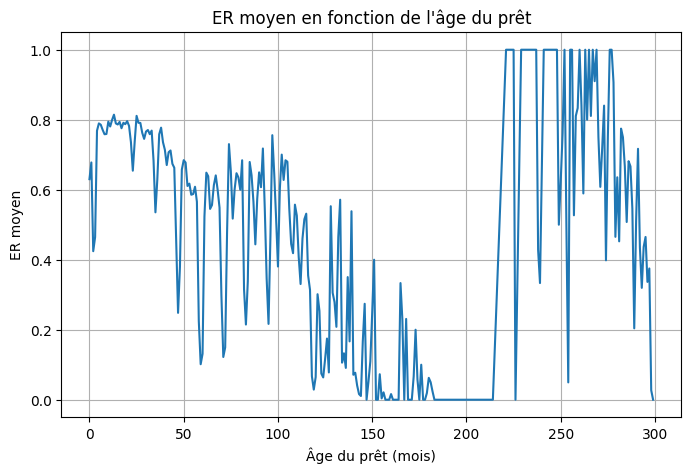

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(er_by_age["AGE_PRET"], er_by_age["ER_obs"])
plt.xlabel("Âge du prêt (mois)")
plt.ylabel("ER moyen")
plt.title("ER moyen en fonction de l'âge du prêt")
plt.grid(True)
plt.show()


**La courbe est toujours assez élevée à mon goût**

In [169]:
flag_by_age = (
    df.groupby("AGE_PRET")["FLAG_ER"]
    .mean()
    .reset_index()
)

flag_by_age.head(15)


,AGE_PRET,FLAG_ER
0,0.0,0.988095
1,1.0,0.987141
2,2.0,0.987627
3,3.0,0.984740
4,4.0,0.985934
5,5.0,0.985673
6,6.0,0.990745
7,7.0,0.992379
8,8.0,0.988931
9,9.0,0.984629


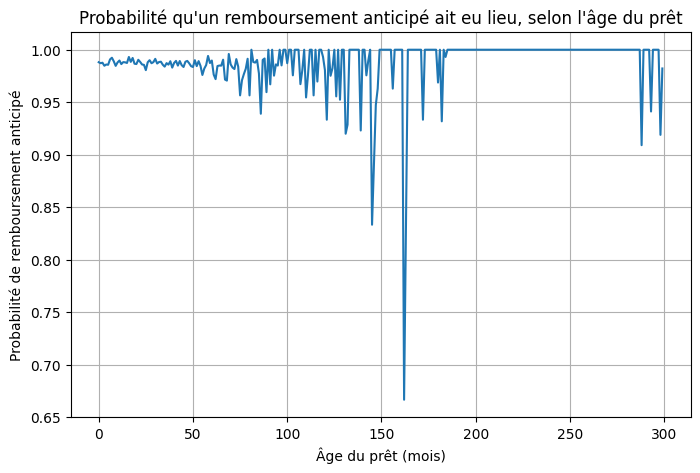

In [170]:
plt.figure(figsize=(8, 5))
plt.plot(flag_by_age["AGE_PRET"], flag_by_age["FLAG_ER"])
plt.xlabel("Âge du prêt (mois)")
plt.ylabel("Probabilité de remboursement anticipé")
plt.title("Probabilité qu'un remboursement anticipé ait eu lieu, selon l'âge du prêt")
plt.grid(True)
plt.show()


**Courbe toujours très élevée à mon goût, mais il y a qd mm environ 98,7% de prets avec RA>0**

**er_by_product pas très utile le prof a dit d'enlever les AR**

In [171]:
er_by_product = (
    df.groupby("produit")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
    .sort_values("taux_ER", ascending=False)
)

er_by_product


,taux_ER,ER_moyen,n_obs
produit,,,
1,0.988715,0.639433,1595
0,0.987111,0.639582,96826


In [172]:
# 1. Création de la variable binaire Flag_EAD
# Astuce Pandas : convertir le booléen (True/False) en entier (1/0)
df["Flag_EAD"] = (df["EAD"] != 0).astype(int)

# 2. Groupby pour calculer la moyenne par âge du prêt
flag_ead_by_age = (
    df.groupby("AGE_PRET")["Flag_EAD"]
    .mean()
    .reset_index()
)

# Affichage des premières lignes pour vérification
print(flag_ead_by_age.head(15))

    AGE_PRET  Flag_EAD
0        0.0  0.285714
1        1.0  0.411474
2        2.0  0.216085
3        3.0  0.152122
4        4.0  0.192455
5        5.0  0.163897
6        6.0  0.171456
7        7.0  0.216342
8        8.0  0.217114
9        9.0  0.193237
10      10.0  0.163484
11      11.0  0.184925
12      12.0  0.147116
13      13.0  0.140187
14      14.0  0.153077


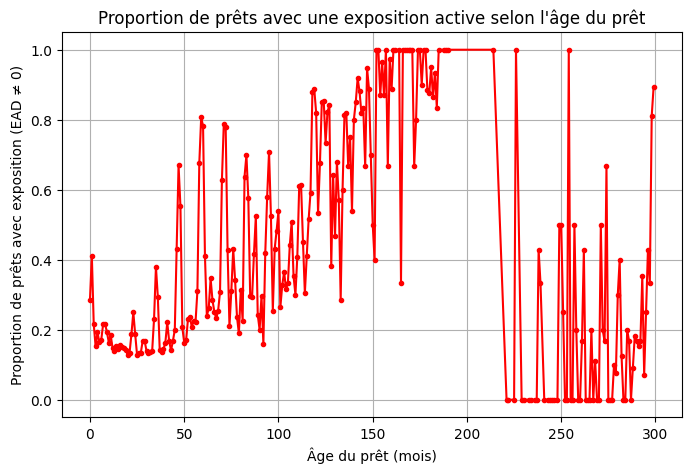

In [173]:
# 3. Tracé du graphique
plt.figure(figsize=(8, 5))
# J'ai mis une couleur différente (ex: rouge) pour bien le distinguer de ton 1er graphique
plt.plot(flag_ead_by_age["AGE_PRET"], flag_ead_by_age["Flag_EAD"], color="red", marker='o', markersize=3) 

plt.xlabel("Âge du prêt (mois)")
plt.ylabel("Proportion de prêts avec exposition (EAD ≠ 0)")
plt.title("Proportion de prêts avec une exposition active selon l'âge du prêt")
plt.grid(True)
plt.show()

**Les vieux prets ont tendance a ne pas faire defaut contrairement au pret de moyen et courrt terme (0-150 mois)**

In [174]:
df["Tx_bin"] = pd.qcut(df["Tx"], q=4, duplicates="drop")

er_by_tx = (
    df.groupby("Tx_bin")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
)

er_by_tx


,taux_ER,ER_moyen,n_obs
Tx_bin,,,
"(-1.501, 2.083]",0.986518,0.601454,24923
"(2.083, 2.178]",0.987032,0.623336,26681
"(2.178, 2.254]",0.986059,0.688529,22236
"(2.254, 2.786]",0.988853,0.651586,24581


In [175]:
df["B_RESMAT_bin"] = pd.cut(df["B_RESMAT"], bins=10)

er_by_resmat = (
    df.groupby("B_RESMAT_bin")
    .agg(
        taux_ER=("FLAG_ER", "mean"),
        ER_moyen=("ER_obs", "mean"),
        n_obs=("ER_obs", "size")
    )
)

er_by_resmat


,taux_ER,ER_moyen,n_obs
B_RESMAT_bin,,,
"(-0.298, 29.8]",0.987948,0.446816,52440
"(29.8, 59.6]",0.988339,0.867293,28214
"(59.6, 89.4]",0.984968,0.849322,7850
"(89.4, 119.2]",0.981801,0.853319,5275
"(119.2, 149.0]",0.980024,0.838204,2503
"(149.0, 178.8]",0.983042,0.835778,1946
"(178.8, 208.6]",0.960938,0.788090,128
"(208.6, 238.4]",0.948718,0.771318,39
"(238.4, 268.2]",1.000000,0.929123,14


In [176]:
df

,ID,AGE_CLI,B_MAT,B_RESMAT,CLASSACT,CSP,DARRET,E_OFF,MREVTOT,MTECH,...,Tx_bin,B_RESMAT_bin,Flag_EAD,t_ecoule,t_bin,t_bin_perso,RA2,Capital_emprunt,Pret,Montant_rembourse
52,a000053,77.0,61.0,14.0,0,30,2019-01-01,0.0,2354.0,144.99,...,"(2.254, 2.786]","(-0.298, 29.8]",0,60,"(50.833, 63.292]",60-120 mois,1631.48,8210.617764,8699.40,6814.53
53,a000054,69.0,48.0,5.0,0,30,2019-01-01,0.0,1262.0,150.81,...,"(2.083, 2.178]","(-0.298, 29.8]",0,48,"(38.375, 50.833]",36-60 mois,990.00,6932.856886,7238.88,6484.83
54,a000055,73.0,48.0,8.0,0,30,2019-01-01,0.0,3651.0,247.04,...,"(-1.501, 2.083]","(-0.298, 29.8]",0,48,"(38.375, 50.833]",36-60 mois,1802.36,11367.802466,11857.92,9881.60
55,a000056,70.0,48.0,8.0,0,30,2019-01-01,0.0,1542.0,123.52,...,"(-1.501, 2.083]","(-0.298, 29.8]",0,48,"(38.375, 50.833]",36-60 mois,902.49,5690.830739,5928.96,4940.80
56,a000057,71.0,48.0,9.0,0,30,2019-01-01,0.0,950.0,148.22,...,"(-1.501, 2.083]","(-0.298, 29.8]",0,48,"(38.375, 50.833]",36-60 mois,1344.42,6820.497415,7114.56,5780.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,a099996,65.0,61.0,1.0,0,30,2023-12-01,0.0,1200.0,187.34,...,"(-1.501, 2.083]","(-0.298, 29.8]",1,18,"(13.458, 25.917]",12-36 mois,7895.84,3317.690259,3372.12,11240.40
99996,a099997,52.0,61.0,44.0,1,40,2023-12-01,0.0,0.0,528.97,...,"(-1.501, 2.083]","(29.8, 59.6]",0,60,"(50.833, 63.292]",60-120 mois,21496.29,30134.807525,31738.20,8992.49
99997,a099998,42.0,73.0,59.0,0,8,2023-12-01,0.0,4468.0,347.93,...,"(-1.501, 2.083]","(29.8, 59.6]",0,72,"(63.292, 75.75]",60-120 mois,18927.31,23529.448011,25050.96,4871.02
99998,a099999,50.0,73.0,61.0,0,8,2023-12-01,0.0,3999.0,229.84,...,"(2.083, 2.178]","(59.6, 89.4]",0,72,"(63.292, 75.75]",60-120 mois,11643.00,15507.971080,16548.48,2758.08


In [177]:
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CF_CAP_OBS', 'ER_obs', 'FLAG_ER',
       'EAD_POST', 'CRD', 'Tx_bin', 'B_RESMAT_bin', 'Flag_EAD', 't_ecoule',
       't_bin', 't_bin_perso', 'RA2', 'Capital_emprunt', 'Pret',
       'Montant_rembourse'],
      dtype='str')

In [178]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


cat_cols = ['CLASSACT', 'CSP', 'produit', 'Tx_bin', 'B_RESMAT_bin']
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

features = ['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CF_CAP_OBS', 'FLAG_ER',
       'EAD_POST', 'Tx_bin', 'B_RESMAT_bin']

X = df[features].fillna(0)  # Matrice explicatives


In [179]:
print("Types après encodage:")
print(X.dtypes)

Types après encodage:
ID                         str
AGE_CLI                float64
B_MAT                  float64
B_RESMAT               float64
CLASSACT                 int64
CSP                      int64
DARRET          datetime64[us]
E_OFF                  float64
MREVTOT                float64
MTECH                  float64
NBIMP                    int64
NB_ECH                   int64
produit                  int64
RA                     float64
Tx                     float64
EAD                    float64
AGE_PRET               float64
HORIZON_RES              int64
CF_CAP_OBS             float64
FLAG_ER                  int64
EAD_POST               float64
Tx_bin                   int64
B_RESMAT_bin             int64
dtype: object


ER corrigé: count    98419.000000
mean         0.639580
std          0.471644
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: ER_obs, dtype: float64
% RA négatifs supprimés: 0.3667916399955294 %


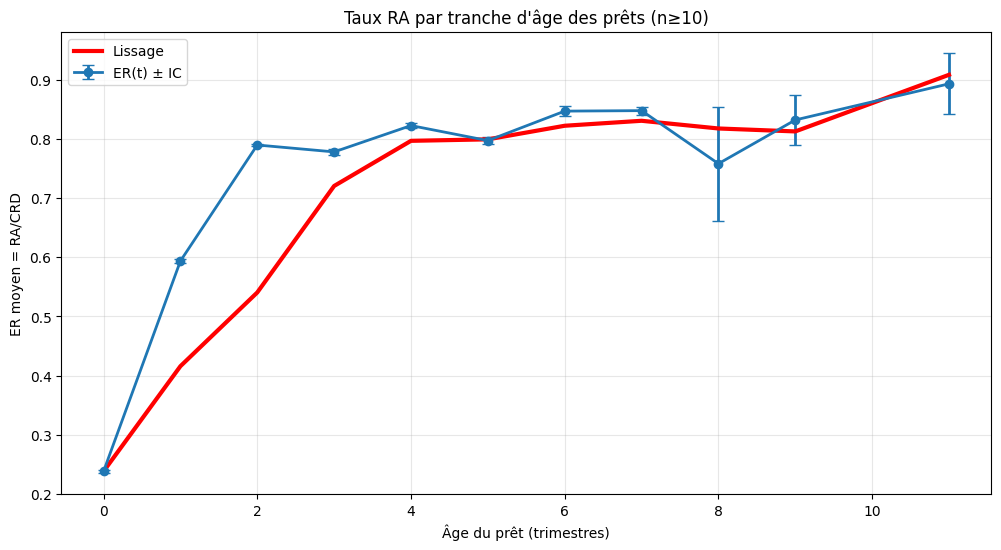

ER par bin temporel (n≥10):
   t_bin   mean    std  count  er_smooth
0      0  0.238  0.421  18134      0.238
1      1  0.594  0.484  26522      0.416
2      2  0.790  0.398  32032      0.541
3      3  0.778  0.400   6642      0.721
4      4  0.823  0.366   6326      0.797
5      5  0.797  0.386   4333      0.799
6      6  0.847  0.342   1740      0.822
7      7  0.848  0.336   2562      0.831
8      8  0.758  0.430     20      0.818
9      9  0.832  0.366     73      0.813
11    11  0.893  0.301     34      0.908


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



print("ER corrigé:", df['ER_obs'].describe())
print("% RA négatifs supprimés:", (df['RA'] < 0).mean()*100, "%")



df['t_ecoule'] = df['NB_ECH']  # ou MATURITE_TOTALE - HORIZON_RES

# 2. BINS TEMPORELS (3 mois = 10+ individus typiquement)
df['t_bin'] = pd.cut(df['t_ecoule'], 
                     bins=12,  # 12 trimestres ou 24 mois
                     labels=range(12))

# 3. AGRÉGER par bin
er_par_t = df.groupby('t_bin')['ER_obs'].agg(['mean', 'std', 'count']).reset_index()
er_par_t['er_smooth'] = er_par_t['mean'].rolling(3, min_periods=1).mean()

# 4. FILTRER bins avec assez d'obs (>10)
er_par_t = er_par_t[er_par_t['count'] >= 4]

# 5. PLOT
plt.figure(figsize=(12, 6))
plt.errorbar(er_par_t['t_bin'], er_par_t['mean'], 
             yerr=er_par_t['std']/np.sqrt(er_par_t['count']), 
             fmt='o-', capsize=4, linewidth=2, label='ER(t) ± IC')
plt.plot(er_par_t['t_bin'], er_par_t['er_smooth'], 'r-', linewidth=3, label='Lissage')

plt.xlabel('Âge du prêt (trimestres)')
plt.ylabel('ER moyen = RA/CRD')
plt.title('Taux d\'ER par tranche d\'âge des prêts (n≥10)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. TABLEAU
print("ER par bin temporel (n≥10):")
print(er_par_t.round(3))


**Tendance croisssante, ce qui est tout a fait normale car ER = RA/CRD et CRD diminue avec le temps**

In [181]:
# Moins d'individus ? → Gros bins
df['t_bin'] = pd.cut(df['t_ecoule'], bins=6, labels=['6m','12m','18m','24m','30m','36m+'])

# Trop d'individus ? → Plus fin
df['t_bin'] = pd.cut(df['t_ecoule'], bins=24)  # Mensuel


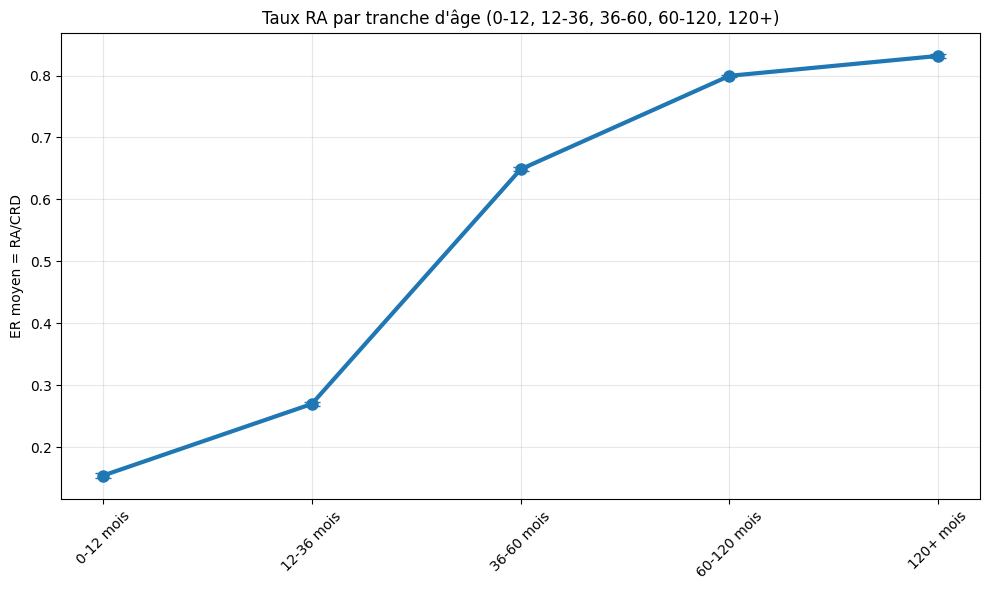

ER par tranche :
   t_bin_perso   mean    std  count
0    0-12 mois  0.155  0.359   7132
1   12-36 mois  0.270  0.437  14857
2   36-60 mois  0.649  0.469  24694
3  60-120 mois  0.800  0.389  37753
4    120+ mois  0.832  0.357  13983


In [182]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 2. BINS PERSO : 0-12, 12-36, 36-60, 60+
bins = [0, 12, 36, 60, 120, float('inf')]
labels = ['0-12 mois', '12-36 mois', '36-60 mois', '60-120 mois', '120+ mois']
df['t_bin_perso'] = pd.cut(df['NB_ECH'], bins=bins, labels=labels, right=False)

# 3. Agréger
er_par_t = df.groupby('t_bin_perso')['ER_obs'].agg(['mean', 'std', 'count']).reset_index()
er_par_t = er_par_t[er_par_t['count'] >= 10]  # Min 10 obs

# 4. PLOT
plt.figure(figsize=(10, 6))
x_pos = range(len(er_par_t))
plt.errorbar(x_pos, er_par_t['mean'], 
             yerr=er_par_t['std']/np.sqrt(er_par_t['count']), 
             fmt='o-', capsize=6, linewidth=3, markersize=8)
plt.xticks(x_pos, er_par_t['t_bin_perso'], rotation=45)
plt.ylabel('ER moyen = RA/CRD')
plt.title('Taux RA par tranche d\'âge (0-12, 12-36, 36-60, 60-120, 120+)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Tableau
print("ER par tranche :")
print(er_par_t[['t_bin_perso', 'mean', 'std', 'count']].round(3))


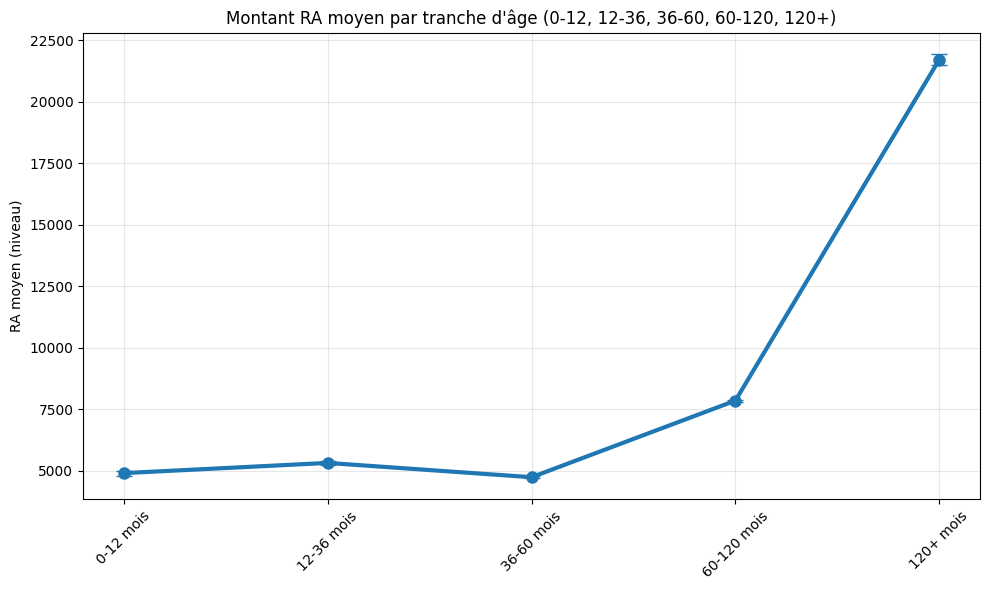

RA moyen par tranche :
   t_bin_perso       mean        std  count
0    0-12 mois   4901.466   8659.840   7134
1   12-36 mois   5315.551   8488.170  14857
2   36-60 mois   4734.412   6170.480  24694
3  60-120 mois   7848.023   8655.923  37753
4    120+ mois  21709.125  26812.405  13983


In [183]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# df["RA2"] = df["RA"].clip(lower=0)

# 2. BINS PERSO : 0-12, 12-36, 36-60, 60+
bins = [0, 12, 36, 60, 120, float('inf')]
labels = ['0-12 mois', '12-36 mois', '36-60 mois', '60-120 mois', '120+ mois']
df['t_bin_perso'] = pd.cut(df['NB_ECH'], bins=bins, labels=labels, right=False)

# 3. Agréger
ra_par_t = df.groupby('t_bin_perso')['RA'].agg(['mean', 'std', 'count']).reset_index()
ra_par_t = ra_par_t[ra_par_t['count'] >= 10]  # Min 10 obs

# 4. PLOT
plt.figure(figsize=(10, 6))
x_pos = range(len(ra_par_t))
plt.errorbar(
    x_pos, 
    ra_par_t['mean'], 
    yerr=ra_par_t['std']/np.sqrt(ra_par_t['count']), 
    fmt='o-', 
    capsize=6, 
    linewidth=3, 
    markersize=8
)
plt.xticks(x_pos, ra_par_t['t_bin_perso'], rotation=45)
plt.ylabel('RA moyen (niveau)')
plt.title('Montant RA moyen par tranche d\'âge (0-12, 12-36, 36-60, 60-120, 120+)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Tableau
print("RA moyen par tranche :")
print(ra_par_t[['t_bin_perso', 'mean', 'std', 'count']].round(3))


In [184]:
df["Tx"]

52       2.298927
53       2.132356
54       2.083425
55       2.022835
56       2.083425
           ...   
99995    2.062293
99996    2.058708
99997    2.083199
99998    2.159916
99999    2.293092
Name: Tx, Length: 98421, dtype: float64

**Création/Calcul de variables qui peuvent être intéressantes**

**Capital emprunté sans les interets**

In [185]:
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + ( df["Tx"] / 1200) ) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))

In [186]:
df["Capital_emprunt"].describe()

count     98421.000000
mean      14604.544690
std       21251.195798
min           0.000000
25%        3566.666016
50%        8466.831365
75%       16603.198965
max      841957.331974
Name: Capital_emprunt, dtype: float64

In [187]:
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CF_CAP_OBS', 'ER_obs', 'FLAG_ER',
       'EAD_POST', 'CRD', 'Tx_bin', 'B_RESMAT_bin', 'Flag_EAD', 't_ecoule',
       't_bin', 't_bin_perso', 'RA2', 'Capital_emprunt', 'Pret',
       'Montant_rembourse'],
      dtype='str')

**Prix total du pret**

In [188]:
df["Pret"] = df["MTECH"] * df["NB_ECH"]

In [189]:
df["Pret"].describe()

count     98421.000000
mean      15950.124400
std       24303.083274
min           0.000000
25%        3752.640000
50%        8904.480000
75%       17658.000000
max      861977.760000
Name: Pret, dtype: float64

**Montant déjà remboursé**

In [190]:
df["Montant_rembourse"] = round((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"],2)

In [191]:
df["Montant_rembourse"].describe()

count    9.842100e+04
mean     8.079537e+03
std      2.270638e+04
min      0.000000e+00
25%      1.612380e+03
50%      4.100600e+03
75%      9.227400e+03
max      4.273973e+06
Name: Montant_rembourse, dtype: float64

**Montant remboursé + remboursements anticipés**

In [192]:
df["Montant_plus_RA"] = df["Montant_rembourse"] + df["RA"].clip(lower=0)

In [193]:
df["Montant_plus_RA"].describe()

count    9.842100e+04
mean     1.654308e+04
std      2.906236e+04
min      0.000000e+00
25%      4.862110e+03
50%      1.009730e+04
75%      1.873020e+04
max      4.273973e+06
Name: Montant_plus_RA, dtype: float64

**Montant qui n'a pas encore été remboursé**

In [202]:
df["Reste_a_rembourser"] = df["Pret"] - df["Montant_plus_RA"]

In [203]:
df["Reste_a_rembourser"].describe()

count    9.842100e+04
mean    -5.929562e+02
std      2.185799e+04
min     -3.411995e+06
25%     -3.135100e+02
50%      1.721400e+02
75%      1.452420e+03
max      3.173729e+05
Name: Reste_a_rembourser, dtype: float64

bizarre qu'il y ait des valeurs négatives, peut etre probleme dans le calcul, je demanderais au prof si vous ne voyez pas l'erreur non plus ?


**Interets à payer du contrat**

In [196]:
df["interets"] = df["Pret"] - df["Capital_emprunt"]

In [197]:
df["interets"].describe()

count     98421.000000
mean       1345.579710
std        3272.349773
min       -2114.530907
25%         137.485246
50%         425.763535
75%        1048.467059
max      148002.092728
Name: interets, dtype: float64

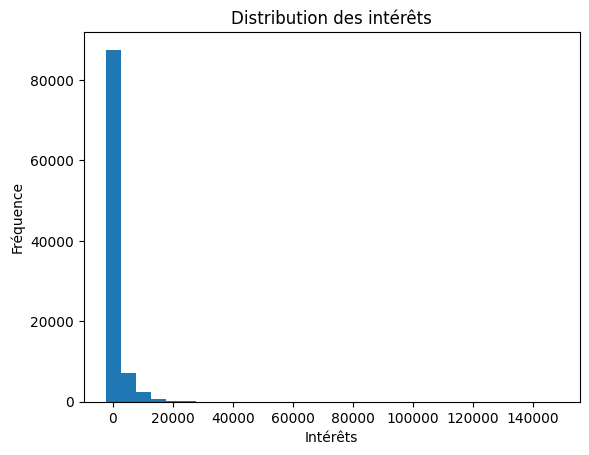

In [198]:
plt.figure()
plt.hist(df["interets"], bins=30)
plt.xlabel("Intérêts")
plt.ylabel("Fréquence")
plt.title("Distribution des intérêts")
plt.show()

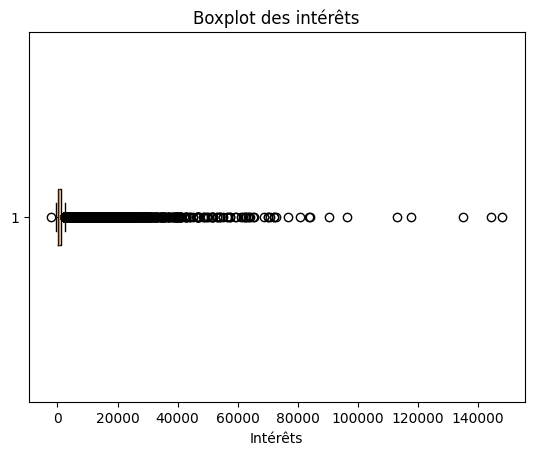

In [199]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["interets"].dropna(), vert=False)
plt.xlabel("Intérêts")
plt.title("Boxplot des intérêts")
plt.show()
